In [11]:
%pip install pycocotools scikit-image ipywidgets ace-tools matplotlib scikit-learn pandas torch torchvision transformers albumentations timm datasets tensorboard diffusers accelerate opencv-python pillow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 22.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 31.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ultralytics] [ultralytics]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK']='1'
os.environ["HF_TOKEN"] = "hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import pylab
import json
import torch
from diffusers.pipelines.controlnet.pipeline_controlnet import StableDiffusionControlNetPipeline
from diffusers.models.controlnets.controlnet import ControlNetModel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from collections import defaultdict
import random
import warnings
import pandas as pd
from ultralytics import YOLO

warnings.filterwarnings("ignore")
pylab.rcParams['figure.figsize'] = (8.0, 10.0)
np.random.seed(42)
np.random.RandomState(42)

RandomState(MT19937) at 0x3370A0440

# Домашнее задание 2.5: Синтетические данные через Stable Diffusion + ControlNet

### Цель

Научиться использовать генеративные модели для аугментации данных, исследовать влияние синтетических примеров на качество модели.

### Задание

1. Выбрать «редкие» классы из своего датасета.

In [3]:
dataDir = '.'
dataType = 'val2017'
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# Получаем все категории
catIds = coco.getCatIds()
cats = coco.loadCats(catIds)
nms = [cat['name'] for cat in cats]

# Считаем количество аннотаций (объектов) для каждой категории
cat_counts = {}
for catId in catIds:
    # Получаем все аннотации для текущей категории
    annIds = coco.getAnnIds(catIds=[catId])
    cat_counts[catId] = len(annIds)

# Сортируем категории по количеству объектов (от самых редких к самым частым)
sorted_cats = sorted(zip(cat_counts.values(), catIds), key=lambda x: x[0])

# Выводим 10 самых редких классов
print("Топ-10 самых редких классов в val2017:")
print("-" * 40)
for count, catId in sorted_cats[:10]:
    cat_name = coco.loadCats([catId])[0]['name']
    print(f"{cat_name:20} : {count:6} объектов")

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Топ-10 самых редких классов в val2017:
----------------------------------------
toaster              :      9 объектов
hair drier           :     11 объектов
scissors             :     36 объектов
microwave            :     55 объектов
toothbrush           :     57 объектов
parking meter        :     60 объектов
snowboard            :     69 объектов
bear                 :     71 объектов
stop sign            :     75 объектов
fire hydrant         :    101 объектов


2. Сгенерировать дополнительные изображения этих классов с помощью Stable Diffusion + ControlNet.

In [9]:
class ControlNetGenerator:
    def __init__(self):
        print("Загрузка моделей...")
        
        # Загружаем ControlNet
        controlnet = ControlNetModel.from_pretrained(
            "lllyasviel/sd-controlnet-depth",
            torch_dtype=torch.float32
        )
        
        # Загружаем пайплайн
        self.pipe = StableDiffusionControlNetPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            controlnet=controlnet,
            torch_dtype=torch.float32,
            safety_checker=None
        )

        self.pipe = self.pipe.to("mps")
        self.pipe.enable_attention_slicing()
        
        print(f"Модели загружены! Используется {self.pipe.device}")
    
    def create_gradient_depth(self, width=512, height=512):
        depth = np.zeros((height, width), dtype=np.uint8)
        for y in range(height):
            depth[y, :] = int(200 * (1 - y / height))
        return Image.fromarray(depth)
    
    def generate(self, prompt, negative_prompt, num_images=1):
        depth_map = self.create_gradient_depth()
        
        if not hasattr(self, '_warmed_up'):
            print("Выполняем warmup pass...")
            _ = self.pipe(
                prompt="warmup",
                image=depth_map,
                num_inference_steps=1
            )
            self._warmed_up = True
        
        result = self.pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=depth_map,
            num_images_per_prompt=num_images,
            num_inference_steps=25,
            guidance_scale=7.5,
            controlnet_conditioning_scale=0.7
        )
        
        return result.images

def generate_all():
    generator = ControlNetGenerator()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    for class_name, prompt in RARE_CLASSES.items():
        print(f"Генерация {class_name}...")
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_dir, exist_ok=True)
        
        for i in tqdm(range(SAMPLES_PER_CLASS), desc=class_name):
            images = generator.generate(prompt, NEGATIVE_PROMPT, num_images=1)
            images[0].save(os.path.join(class_dir, f"{class_name}_{i:04d}.png"))
        
        print(f"{class_name}: готово")

# Редкие классы из COCO
RARE_CLASSES = {
    # 'toaster': 'a modern toaster on a kitchen counter, high quality, photorealistic',
    # 'hair drier': 'a hair drier on a bathroom sink or in a hand, high quality, photorealistic',
    # 'scissors': 'metal scissors on white background or cutting paper, high quality, photorealistic',
    # 'microwave': 'a microwave oven on a kitchen counter, high quality, photorealistic',
    'toothbrush': 'a white toothbrush in a hand, high quality, photorealistic'
}

NEGATIVE_PROMPT = "blurry, low quality, watermark, text"
SAMPLES_PER_CLASS = 20  # Количество изображений на класс
OUTPUT_DIR = "val2017/synthetic"

generate_all()
print(f"Генерация завершена! Результаты в папке {OUTPUT_DIR}")

Загрузка моделей...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Модели загружены! Используется mps:0
Генерация toothbrush...


...

  0%|          | 0/25 [00:00<?, ?it/s]

toothbrush:  95%|█████████▌| 19/20 [05:07<00:16, 16.12s/it]

  0%|          | 0/25 [00:00<?, ?it/s]

toothbrush: 100%|██████████| 20/20 [05:23<00:00, 16.19s/it]

toothbrush: готово
Генерация завершена! Результаты в папке val2017/synthetic


3. Добавить синтетику в тренировочный датасет.

In [ ]:
class BBoxDetector:
    def __init__(self):
        # Используем легковесную модель YOLO
        self.model = YOLO("yolov8n.pt")
        
    def get_bbox(self, image):
        results = self.model(image, verbose=False)
        
        if len(results[0].boxes) > 0:
            box = results[0].boxes[0].xyxy[0].tolist()
            x1, y1, x2, y2 = box
            return [x1, y1, x2 - x1, y2 - y1]
        
        width, height = image.size
        return [width*0.2, height*0.2, width*0.6, height*0.6]

class DatasetAugmenter:
    def __init__(self, coco_ann_file, synthetic_dir):
        self.coco = COCO(coco_ann_file)
        self.synthetic_dir = synthetic_dir
        
    def create_synthetic_annotations(self):
        synthetic_annotations = {
            "images": [],
            "annotations": [],
            "categories": self.coco.dataset['categories']
        }
        
        ann_id = max([ann['id'] for ann in self.coco.dataset['annotations']]) + 1
        img_id = max([img['id'] for img in self.coco.dataset['images']]) + 1
        
        for class_name in os.listdir(self.synthetic_dir):
            class_dir = os.path.join(self.synthetic_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            # Находим category_id
            cat_id = None
            for cat in self.coco.dataset['categories']:
                if cat['name'].lower() == class_name.lower():
                    cat_id = cat['id']
                    break
            
            if cat_id is None:
                continue
            
            for img_file in os.listdir(class_dir):
                if not img_file.endswith(('.png', '.jpg')):
                    continue
                    
                img_path = os.path.join(class_dir, img_file)
                img = Image.open(img_path)
                width, height = img.size

                detector = BBoxDetector()
                bbox = detector.get_bbox(img)
                
                synthetic_annotations["images"].append({
                    "id": img_id,
                    "file_name": f"synthetic/{class_name}/{img_file}",
                    "width": width,
                    "height": height
                })
                
                synthetic_annotations["annotations"].append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": cat_id,
                    "bbox": bbox,
                    "area": bbox[2] * bbox[3],
                    "iscrowd": 0
                })
                
                img_id += 1
                ann_id += 1
        
        return synthetic_annotations
    
    def merge_datasets(self, original_ann_file, output_ann_file):
        with open(original_ann_file, 'r') as f:
            original_data = json.load(f)
        
        synthetic_data = self.create_synthetic_annotations()
        merged_data = original_data.copy()
        merged_data['images'].extend(synthetic_data['images'])
        merged_data['annotations'].extend(synthetic_data['annotations'])
        
        with open(output_ann_file, 'w') as f:
            json.dump(merged_data, f)
        
        print(f"Merged dataset saved to {output_ann_file}")
        print(f"Added {len(synthetic_data['images'])} synthetic images")
        print(f"Added {len(synthetic_data['annotations'])} synthetic annotations")

augmenter = DatasetAugmenter('annotations/instances_val2017.json', 'val2017/synthetic')
augmenter.merge_datasets('annotations/instances_val2017.json', 'annotations/instances_val2017_augmented.json')

loading annotations into memory...
Done (t=0.28s)
creating index...
index created!
Merged dataset saved to annotations/instances_val2017_augmented.json
Added 100 synthetic images
Added 100 synthetic annotations


4. Провести обучение базовой модели (CNN или ViT) без синтетики и с синтетикой.

In [3]:
def stratified_split_coco(val_ann_file, output_dir='split_dataset', train_ratio=0.8):
    
    with open(val_ann_file, 'r') as f:
        coco_data = json.load(f)
    
    img_to_classes = defaultdict(set)
    for ann in coco_data['annotations']:
        img_to_classes[ann['image_id']].add(ann['category_id'])
    
    all_img_ids = list(img_to_classes.keys())
    
    img_groups = defaultdict(list)
    for img_id in all_img_ids:
        num_classes = len(img_to_classes[img_id])
        img_groups[num_classes].append(img_id)
    
    train_img_ids = set()
    test_img_ids = set()
    
    random.seed(42)
    for num_classes, img_ids in img_groups.items():
        random.shuffle(img_ids)
        split_idx = int(len(img_ids) * train_ratio)
        train_img_ids.update(img_ids[:split_idx])
        test_img_ids.update(img_ids[split_idx:])
    
    print(f"Всего: {len(all_img_ids)} изображений")
    print(f"Train: {len(train_img_ids)} ({len(train_img_ids)/len(all_img_ids)*100:.1f}%)")
    print(f"Test: {len(test_img_ids)} ({len(test_img_ids)/len(all_img_ids)*100:.1f}%)")
    
    # Сохраняем (как в первом способе)
    def save_split(img_ids, name):
        filtered = {
            'info': coco_data.get('info', {}),
            'licenses': coco_data.get('licenses', []),
            'categories': coco_data['categories'],
            'images': [img for img in coco_data['images'] if img['id'] in img_ids],
            'annotations': [ann for ann in coco_data['annotations'] if ann['image_id'] in img_ids]
        }
        
        os.makedirs(output_dir, exist_ok=True)
        with open(os.path.join(output_dir, f'instances_{name}.json'), 'w') as f:
            json.dump(filtered, f)
    
    save_split(train_img_ids, 'train')
    save_split(test_img_ids, 'test')

In [ ]:
class COCODetectionDataset(Dataset):
    def __init__(self, ann_file, img_dir, transform=None, class_ids=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.transform = transform
        self.class_ids = class_ids or self.coco.getCatIds()
        self.img_ids = []
        for class_id in self.class_ids:
            self.img_ids.extend(self.coco.getImgIds(catIds=[class_id]))
        self.img_ids = list(set(self.img_ids))
        
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        img = Image.open(img_path).convert('RGB')
        ann_ids = self.coco.getAnnIds(imgIds=[img_id], catIds=self.class_ids)
        annotations = self.coco.loadAnns(ann_ids)
        
        target = torch.zeros(len(self.class_ids))
        for ann in annotations:
            class_idx = self.class_ids.index(ann['category_id'])
            target[class_idx] = 1
        
        if self.transform:
            img = self.transform(img)
        
        return img, target

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='mps'):
    model = model.to(device)
    train_losses = []
    val_metrics = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        metrics = evaluate_model(model, val_loader, device)
        val_metrics.append(metrics)
    
    return model, train_losses, val_metrics

def evaluate_model(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels.flatten(), all_preds.flatten())
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def run_experiment(epochs = 10):
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    batch_size = 64
    num_epochs = epochs
    
    # Трансформации
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    rare_class_names = ['toaster', 'hair drier', 'scissors', 'microwave', 'toothbrush']
    coco = COCO('annotations/instances_val2017.json')
    class_ids = []
    for name in rare_class_names:
        ids = coco.getCatIds(catNms=[name])
        if ids:
            class_ids.extend(ids)
    
    print("="*30)
    print("Training on original data only")
    print("="*30)

    stratified_split_coco('annotations/instances_val2017.json')
    
    train_dataset_orig = COCODetectionDataset(
        'split_dataset/instances_train.json', 
        'val2017', 
        transform=transform,
        class_ids=class_ids
    )
    val_dataset = COCODetectionDataset(
        'split_dataset/instances_test.json', 
        'val2017', 
        transform=transform,
        class_ids=class_ids
    )
    
    train_loader_orig = DataLoader(train_dataset_orig, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model_orig = models.resnet50(pretrained=True)
    model_orig.fc = nn.Linear(model_orig.fc.in_features, len(class_ids))
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model_orig.parameters(), lr=0.001)
    
    model_orig, _, metrics_orig = train_model(
        model_orig, train_loader_orig, val_loader, 
        criterion, optimizer, num_epochs, device
    )
    
    print("="*30)
    print("Training on original + synthetic data")
    print("="*30)

    coco = COCO('annotations/instances_val2017_augmented.json')
    class_ids = []
    for name in rare_class_names:
        ids = coco.getCatIds(catNms=[name])
        if ids:
            class_ids.extend(ids)

    stratified_split_coco('annotations/instances_val2017_augmented.json')
    
    train_dataset_aug = COCODetectionDataset(
        'split_dataset/instances_train.json', 
        'val2017', 
        transform=transform,
        class_ids=class_ids
    )

    val_dataset_aug = COCODetectionDataset(
        'split_dataset/instances_test.json', 
        'val2017', 
        transform=transform,
        class_ids=class_ids
    )
    
    train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
    val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False)
    
    model_aug = models.resnet50(pretrained=True)
    model_aug.fc = nn.Linear(model_aug.fc.in_features, len(class_ids))
    
    optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)
    
    model_aug, _, metrics_aug = train_model(
        model_aug, train_loader_aug, val_loader, 
        criterion, optimizer_aug, num_epochs, device
    )
    
    return metrics_orig[-1], metrics_aug[-1]

final_metrics_orig_5, final_metrics_aug_5 = run_experiment(epochs = 5)
final_metrics_orig_8, final_metrics_aug_8 = run_experiment(epochs = 8)
final_metrics_orig_10, final_metrics_aug_10 = run_experiment(epochs = 10)

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
Training on original data only
Всего: 4952 изображений
Train: 3955 (79.9%)
Test: 997 (20.1%)
loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


Epoch 5/5: 100%|██████████| 2/2 [00:01<00:00,  1.70it/s]


Training on original + synthetic data
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Всего: 5052 изображений
Train: 4035 (79.9%)
Test: 1017 (20.1%)
loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


Epoch 5/5: 100%|██████████| 3/3 [00:02<00:00,  1.33it/s]


loading annotations into memory...
Done (t=0.33s)
creating index...
index created!
Training on original data only
Всего: 4952 изображений
Train: 3955 (79.9%)
Test: 997 (20.1%)
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


...

Epoch 8/8: 100%|██████████| 3/3 [00:02<00:00,  1.38it/s]


loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
Training on original data only
Всего: 4952 изображений
Train: 3955 (79.9%)
Test: 997 (20.1%)
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


Epoch 10/10: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]


Training on original + synthetic data
loading annotations into memory...
Done (t=0.41s)
creating index...
index created!
Всего: 5052 изображений
Train: 4035 (79.9%)
Test: 1017 (20.1%)
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


Epoch 10/10: 100%|██████████| 3/3 [00:02<00:00,  1.38it/s]


5. Сравнить метрики и построить таблицу результатов (ablation).

In [16]:
def create_ablation_table(metrics_orig, metrics_aug):
    """Создание таблицы результатов ablation study"""
    
    # Подготовка данных
    results = {
        'Model': ['Baseline (No Synthetic)', 'Ours (+Synthetic Data)'],
        'Accuracy': [metrics_orig['accuracy'], metrics_aug['accuracy']],
        'Precision': [metrics_orig['precision'], metrics_aug['precision']],
        'Recall': [metrics_orig['recall'], metrics_aug['recall']],
        'F1-Score': [metrics_orig['f1_score'], metrics_aug['f1_score']]
    }
    
    df = pd.DataFrame(results)
    
    # Вычисляем улучшение
    improvements = {}
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
        improvement = (metrics_aug[metric] - metrics_orig[metric]) * 100
        improvements[metric] = improvement
    
    # Добавляем строку с улучшениями
    improvement_row = pd.DataFrame({
        'Model': ['Improvement (%)'],
        'Accuracy': [f"{improvements['accuracy']:.2f}%"],
        'Precision': [f"{improvements['precision']:.2f}%"],
        'Recall': [f"{improvements['recall']:.2f}%"],
        'F1-Score': [f"{improvements['f1_score']:.2f}%"]
    })
    
    df = pd.concat([df, improvement_row], ignore_index=True)
    
    return df

def plot_comparison(metrics_orig, metrics_aug):
    """Визуализация сравнения метрик"""
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    orig_values = [metrics_orig['accuracy'], metrics_orig['precision'], 
                   metrics_orig['recall'], metrics_orig['f1_score']]
    aug_values = [metrics_aug['accuracy'], metrics_aug['precision'],
                  metrics_aug['recall'], metrics_aug['f1_score']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, orig_values, width, label='Baseline (No Synthetic)', color='skyblue')
    bars2 = ax.bar(x + width/2, aug_values, width, label='+ Synthetic Data', color='lightcoral')
    
    ax.set_ylabel('Score')
    ax.set_title('Ablation Study: Impact of Synthetic Data on Rare Classes')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('ablation_comparison.png', dpi=300)
    plt.show()

                  Model  Accuracy Precision    Recall  F1-Score
Baseline (No Synthetic)  0.754545  0.202198  0.333333  0.203333
 Ours (+Synthetic Data)  0.772727  0.342308      0.34  0.259649
        Improvement (%)     1.82%    14.01%     0.67%     5.63%


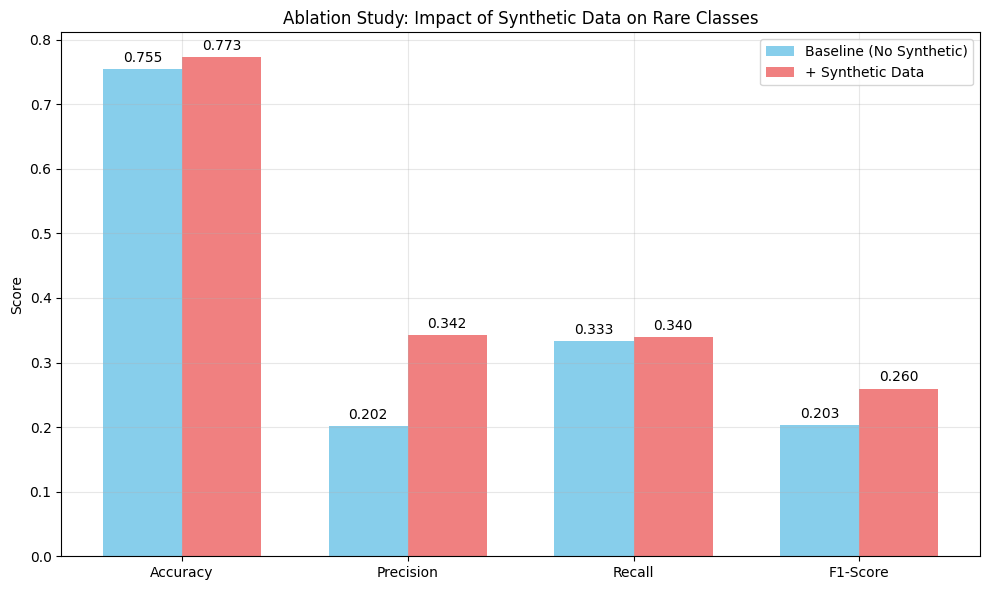

In [17]:
metrics_orig, metrics_aug = final_metrics_orig_5, final_metrics_aug_5
ablation_table = create_ablation_table(metrics_orig, metrics_aug)
print(ablation_table.to_string(index=False))

# Визуализируем результаты
plot_comparison(metrics_orig, metrics_aug)

                  Model  Accuracy Precision    Recall  F1-Score
Baseline (No Synthetic)  0.627273  0.018182       0.2  0.033333
 Ours (+Synthetic Data)  0.890909      0.83  0.753333  0.740952
        Improvement (%)    26.36%    81.18%    55.33%    70.76%


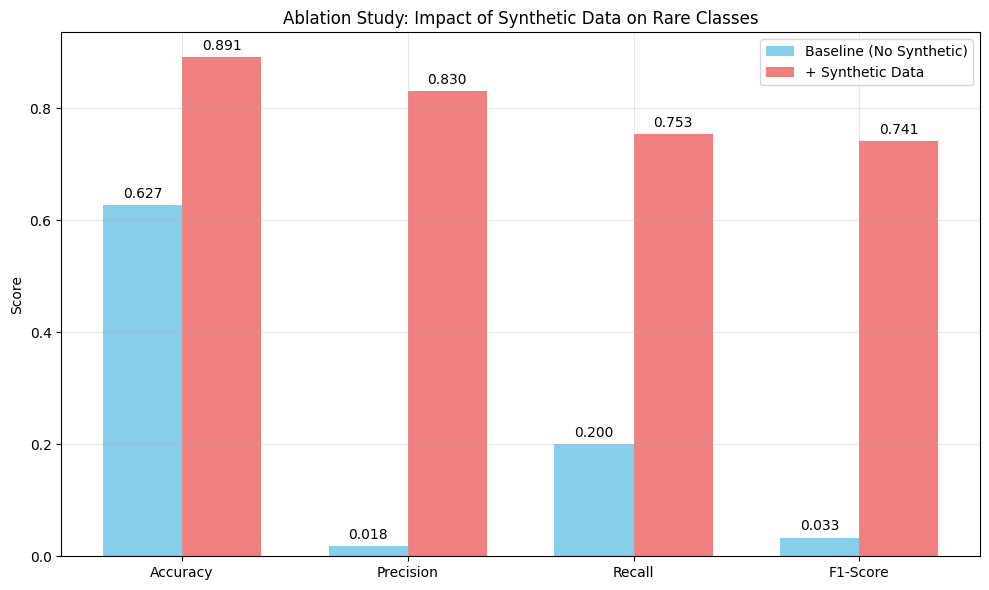

In [18]:
metrics_orig, metrics_aug = final_metrics_orig_8, final_metrics_aug_8
ablation_table = create_ablation_table(metrics_orig, metrics_aug)
print(ablation_table.to_string(index=False))

# Визуализируем результаты
plot_comparison(metrics_orig, metrics_aug)

                  Model  Accuracy Precision    Recall  F1-Score
Baseline (No Synthetic)  0.781818  0.261538  0.248889  0.211966
 Ours (+Synthetic Data)  0.918182  0.831429  0.771111  0.787473
        Improvement (%)    13.64%    56.99%    52.22%    57.55%


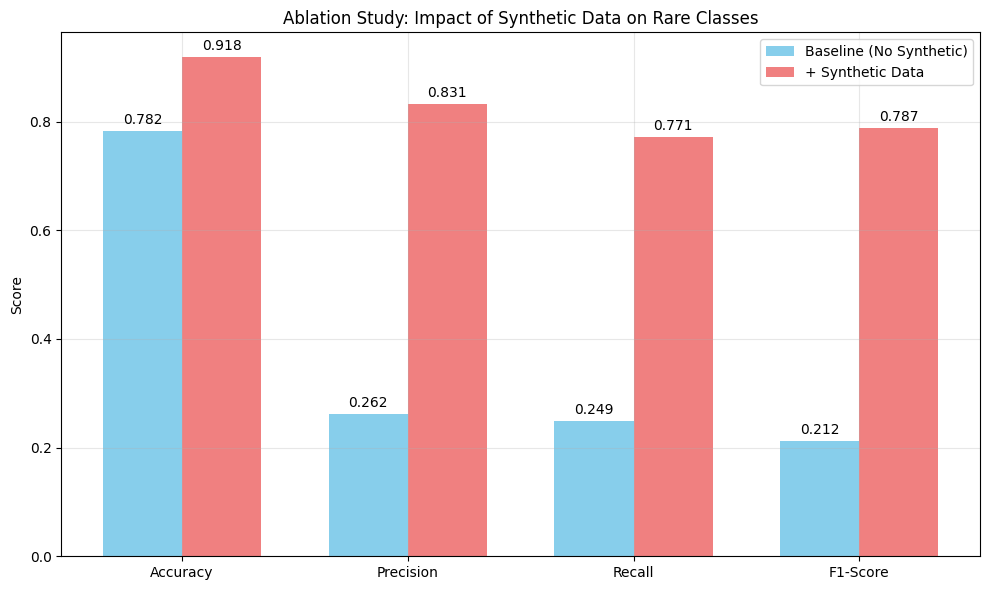

In [19]:
metrics_orig, metrics_aug = final_metrics_orig_10, final_metrics_aug_10
ablation_table = create_ablation_table(metrics_orig, metrics_aug)
print(ablation_table.to_string(index=False))

# Визуализируем результаты
plot_comparison(metrics_orig, metrics_aug)

loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
Найдено 100 синтетических изображений


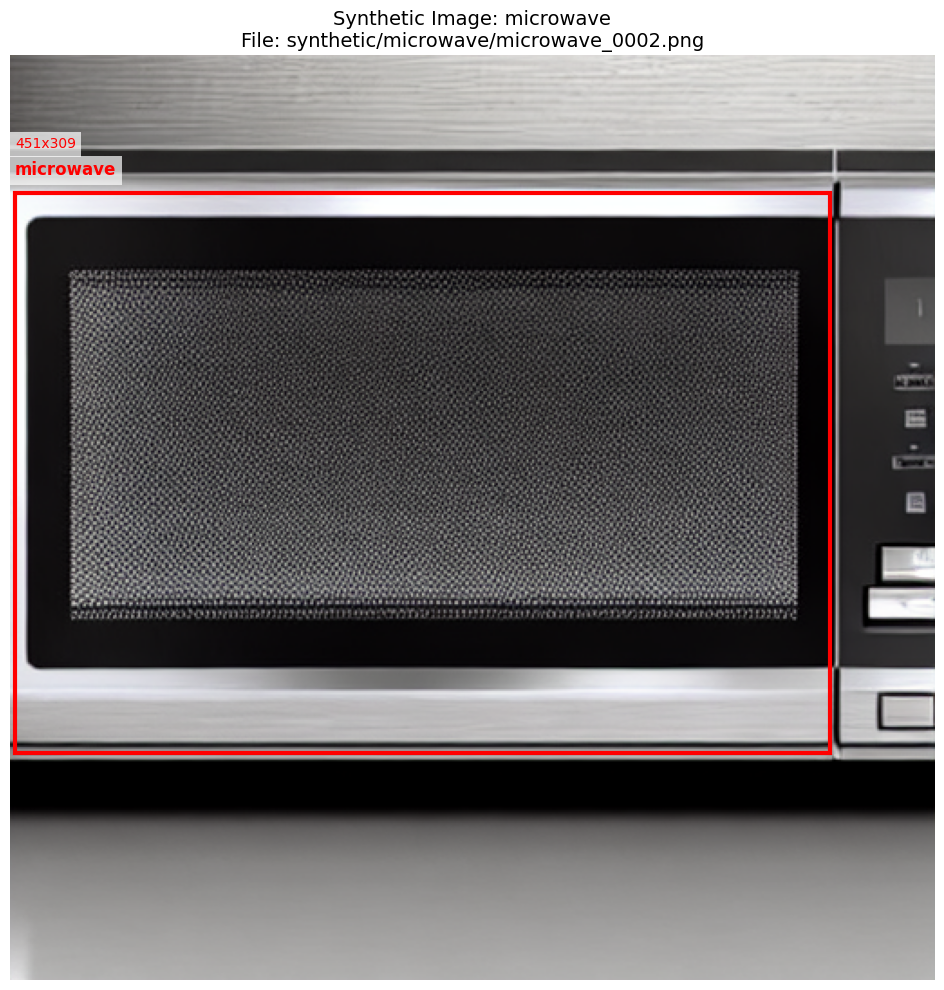

In [ ]:
def visualize_synthetic_example(ann_file, synthetic_img_dir='synthetic'):
    coco = COCO(ann_file)
    
    # Получаем ТОЛЬКО синтетические изображения (их file_name начинается с "synthetic/")
    all_img_ids = coco.getImgIds()
    synthetic_img_ids = []
    
    for img_id in all_img_ids:
        img_info = coco.loadImgs(img_id)[0]
        if img_info['file_name'].startswith('synthetic/'):
            synthetic_img_ids.append(img_id)
    
    print(f"Найдено {len(synthetic_img_ids)} синтетических изображений")
    
    # Выбираем случайное синтетическое изображение
    random_img_id = random.choice(synthetic_img_ids)
    img_info = coco.loadImgs(random_img_id)[0]
    
    img_path = os.path.join(synthetic_img_dir, img_info['file_name'].replace('synthetic/', ''))
    img = Image.open(img_path).convert('RGB')
    
    # Получаем аннотации
    ann_ids = coco.getAnnIds(imgIds=[random_img_id])
    annotations = coco.loadAnns(ann_ids)
    
    # Визуализация
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    
    colors = ['red', 'green', 'blue', 'orange', 'purple']
    for i, ann in enumerate(annotations):
        bbox = ann['bbox']
        x, y, w, h = bbox
        color = colors[i % len(colors)]
        
        # Рисуем bbox
        rect = plt.Rectangle((x, y), w, h, edgecolor=color, facecolor='none', linewidth=3)
        plt.gca().add_patch(rect)
        
        # Добавляем название класса
        category_id = ann['category_id']
        category_name = coco.loadCats([category_id])[0]['name']
        plt.text(x, y - 10, category_name, color=color, fontsize=12, 
                weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Добавляем информацию о размере bbox
        plt.text(x, y - 25, f'{int(w)}x{int(h)}', color=color, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    plt.axis('off')
    plt.title(f'Synthetic Image: {category_name}\nFile: {img_info["file_name"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_synthetic_example('annotations/instances_val2017_augmented.json', 'val2017/synthetic')